# Switching Mechanism

**RQ1 placement, RQ2 handover, on references that are exact.**

Four properties carry the mechanism, and each one is measured here against a
closed-form value rather than against a numerical reference:

1. **Placement.** The crossing is localized by bisection between two
   communication points, so the switch does not sit on the grid.
2. **Region selection with hysteresis.** Each boundary is a Schmitt trigger: it
   arms at `breakpoint + band` while the key rises and at `breakpoint - band`
   while it falls, so the same boundary switches at two different key values.
3. **State adaptation.** The modes store their state in different
   representations, so `_adapt_state` computes the target state instead of
   copying it. What the canonical interface does not carry is lost, and that
   loss is measured.
4. **Partners keep running.** A second component consumes the wrapper's output
   and advances across every switch without re-initialization.

Experiment 1 is the two-mode integrator with a single analytic crossing, kept
unchanged so its numbers remain comparable. Experiment 2 adds the three-region
map, the hysteresis, the adaptation and the partner. The case-study notebooks
measure the same quantities where the reference is itself numerical.


In [8]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import display

sys.path.insert(0, str(Path.cwd().resolve()))
from evidence import repo_root

REPO = repo_root()

from plot_setup import FULL_WIDTH, set_professional_style
from record import record, paper_results_dir

# Recorded numbers belong to the paper repository, not to this one.
RESULTS, _results_source = paper_results_dir(REPO)

plt = set_professional_style(latex=True)
print(f"repository root resolved: {REPO.name}")
print(f"results destination      : {_results_source}")

repository root resolved: SystemSimulation
results destination      : sibling SysSimX-Framework-Paper checkout


## Experiment 1 — placement against an exact crossing

A generated region boundary switches from mode A to mode B when the state reaches
`X_SWITCH`. The hybrid algorithm localizes that crossing by bisection; the
analytical solution is piecewise linear with slope `K_A` before it and `K_B`
after. Both modes share one state format, so the handover residual is zero by
construction. That is the floor Experiment 2 and the case study are measured
against.


In [9]:
from syssimx.core.base import CoSimComponent
from syssimx.core.multi_comp import ModeKey, MultiComponent
from syssimx.core.port import PortSpec, PortType
from syssimx.system.algorithms.hybrid import HybridAlgorithm
from syssimx.system.system import System

K_A, K_B = 1.0, 2.0
# Chosen so the crossing is not a multiple of the macro step: with K_A = 1
# the switch is due at t = X_SWITCH, and 0.53 / 0.05 = 10.6.
X_SWITCH = 0.53
T0, T_END, MACRO_DT = 0.0, 1.0, 0.05
SWITCH_BAND = 1e-6
TOL_TIME = 1e-10
TOL_VALUE = 0.0

FIGURE_ID = "V1_mechanism"
OUT_DIR = REPO / "notebooks" / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)


class GainIntegrator(CoSimComponent):
    """Scalar integrator with gain-dependent autonomous dynamics."""

    def __init__(self, name: str, gain: float):
        super().__init__(name, label=name)
        self.gain = float(gain)
        self.x = 0.0
        self.output_specs = {"x": PortSpec(name="x", type=PortType.REAL, direction="out")}

    def _initialize_component(self, t0): self.x = 0.0
    def _do_step_internal(self, t, dt): self.x += self.gain * dt
    def _update_output_states(self, t=None, event_names=None): self.outputs["x"].set(self.x, t=t)
    def get_state(self): return {"x": self.x}
    def snapshot_state(self): return {"x": self.x}
    def restore_state(self, snapshot, t): self.x = float(snapshot["x"])

    def set_state(self, state, t):
        self.x = float(state["x"])
        self.t = t
        if "x" in self.outputs:
            self._update_output_states(t)


class SwitchingGain(MultiComponent):
    """Two gains behind one interface. Both modes share the state format."""

    def __init__(self, name="SwitchingGain", initial_mode: ModeKey = "A"):
        super().__init__(
            name=name,
            models={"A": GainIntegrator(f"{name}_A", K_A), "B": GainIntegrator(f"{name}_B", K_B)},
            initial_mode=initial_mode,
        )
        self._unify_ports()

    def _adapt_state(self, state, target_mode):
        return {"x": float(state["x"])}


def analytical_x(t):
    t = np.asarray(t, dtype=float)
    t_switch = X_SWITCH / K_A
    return np.where(t <= t_switch, K_A * t, X_SWITCH + K_B * (t - t_switch))

In [10]:
plant_exact = SwitchingGain()
plant_exact.record_switch_state = True
plant_exact.set_switch_regions(
    key=lambda comp: float(comp.outputs["x"].get()),
    breakpoints=(X_SWITCH - SWITCH_BAND,),
    modes=("A", "B"),
    band=SWITCH_BAND,
)

system_exact = System(name="SwitchingGainVerification")
system_exact.add_component(plant_exact)
system_exact.algorithm = HybridAlgorithm()
system_exact.initialize(T0)
system_exact.algorithm.tol_time = TOL_TIME
# Disable the indicator-value early exit so this test isolates the bracket-width
# stopping rule represented by tol_time.
system_exact.algorithm.tol_value = TOL_VALUE
system_exact.run(t0=T0, tf=T_END, dt=MACRO_DT)

times, history = system_exact.get_history()[plant_exact.name]
times = np.asarray(times, dtype=float)
x_num = np.asarray(history["x"], dtype=float)

assert len(plant_exact.switch_events) == 1, plant_exact.switch_events
exact_event = plant_exact.switch_events[0]
t_switch_exact = X_SWITCH / K_A
max_abs_error = float(np.max(np.abs(x_num - analytical_x(times))))
placement_error = abs(float(exact_event.time) - t_switch_exact)
# Distance from the exact crossing to the next communication point. This is a
# timestamp-snapping counterfactual, not an executed trajectory comparison.
grid_counterfactual = (
    np.ceil(t_switch_exact / MACRO_DT) * MACRO_DT - t_switch_exact
)
transfer_error = abs(
    float(exact_event.target_state["x"]) - float(exact_event.source_state["x"])
)

display(pd.Series({
    "switches dispatched": len(plant_exact.switch_events),
    "transition": f"{exact_event.from_mode} -> {exact_event.to_mode}",
    "switch time (s)": f"{exact_event.time:.12f}",
    "analytic switch time (s)": f"{t_switch_exact:.12f}",
    "placement error (s)": f"{placement_error:.2e}",
    "grid-snap counterfactual (s)": f"{grid_counterfactual:.2e}",
    "state discontinuity at transfer": f"{transfer_error:.2e}",
    "max |x - x_exact|": f"{max_abs_error:.2e}",
}).to_frame("value"))

assert (exact_event.from_mode, exact_event.to_mode) == ("A", "B")
assert transfer_error == 0.0, "the handover introduced a discontinuity"
assert placement_error <= 1.01 * TOL_TIME, (
    f"placement error {placement_error:.2e} exceeds tol_time {TOL_TIME:.2e}"
)
assert abs(abs(float(exact_event.time) - t_switch_exact) - placement_error) < 1e-15
assert max_abs_error <= 2 * TOL_TIME, (
    f"state error {max_abs_error:.2e} exceeds the time-localization floor"
)
assert grid_counterfactual > 0.1 * MACRO_DT, (
    f"the analytic crossing sits {grid_counterfactual:.2e} s from the next "
    f"communication point, too close for the counterfactual to mean anything"
)
print("OK: one localized switch, exact state handover, analytic agreement.")

,value
switches dispatched,1
transition,A -> B
switch time (s),0.529999999981
analytic switch time (s),0.530000000000
placement error (s),1.86e-11
grid-snap counterfactual (s),2.00e-02
state discontinuity at transfer,0.00e+00
max |x - x_exact|,1.81e-10


OK: one localized switch, exact state handover, analytic agreement.


## Experiment 2 — region map, hysteresis, adaptation, partner

Three ordered regions on the same scalar key, and a drive that reverses at
`T_REVERSE`, so every boundary is crossed once upward and once downward. The
armed edge differs by direction, which is what makes the boundary a Schmitt
trigger and what the figure shows.

The three modes ramp at different rates and **store their state differently**:
mode `m` keeps `q = x / scale[m]`, so the canonical quantity `x` has to be
reconstructed on both sides of a handover. Each model also accumulates the path
length it has travelled, which the canonical interface does not carry; it is
therefore lost at every switch, and the amount is recorded.

`Partner` integrates the wrapper's output. It is an ordinary coupled component
with no knowledge of the switching.


In [11]:
from dataclasses import dataclass

from syssimx import Connection

BREAKPOINTS = (0.5, 1.5)
BAND = 0.08                      # visible on purpose; the case study uses 0.005 rad
MODES = ("SLOW", "MID", "FAST")
GAINS = {"SLOW": 1.0, "MID": 2.0, "FAST": 4.0}
# The state representation each mode stores: x = SCALES[mode] * q.
SCALES = {"SLOW": 1.0, "MID": 2.0, "FAST": 0.5}
T_REVERSE = 1.4                  # a multiple of REGION_DT, so no step straddles it
REGION_T_END = 2.6
REGION_DT = 0.05
REGION_TOL_TIME = 1e-8
REGION_TOL_VALUE = 0.0


def drive_direction(t: float) -> float:
    """Global ramp direction. Reverses once, so each boundary is crossed twice."""
    return 1.0 if t < T_REVERSE else -1.0


class ScaledRamp(CoSimComponent):
    """Ramp whose state is stored scaled, plus a path length the interface drops."""

    def __init__(self, name: str, gain: float, scale: float):
        super().__init__(name, label=name)
        self.gain = float(gain)
        self.scale = float(scale)
        self.q = 0.0
        self.path = 0.0
        self.output_specs = {"x": PortSpec(name="x", type=PortType.REAL, direction="out")}

    @property
    def x(self) -> float:
        return self.scale * self.q

    def _initialize_component(self, t0):
        self.q, self.path = 0.0, 0.0

    def _do_step_internal(self, t, dt):
        dx = drive_direction(t) * self.gain * dt
        self.q += dx / self.scale
        self.path += abs(dx)

    def _update_output_states(self, t=None, event_names=None):
        self.outputs["x"].set(self.x, t=t)

    # `path` travels through snapshot and restore because bisection rolls the
    # model back; dropping it there would fake a loss that the handover did not
    # cause.
    def get_state(self):
        return {"q": self.q, "path": self.path}

    def snapshot_state(self):
        return {"q": self.q, "path": self.path}

    def restore_state(self, snapshot, t):
        self.q, self.path = float(snapshot["q"]), float(snapshot["path"])

    def set_state(self, state, t):
        self.q, self.path = float(state["q"]), float(state.get("path", 0.0))
        self.t = t
        if "x" in self.outputs:
            self._update_output_states(t)


class TriModePlant(MultiComponent):
    """Three ramps behind one interface, each with its own state representation."""

    def __init__(self, name="TriModePlant"):
        super().__init__(
            name=name,
            models={m: ScaledRamp(f"{name}_{m}", GAINS[m], SCALES[m]) for m in MODES},
            initial_mode=MODES[0],
        )
        self._unify_ports()

    def _adapt_state(self, state, target_mode):
        """Reconstruct canonical x, rescale it, and discard non-interface path."""
        x = self.active_comp.scale * float(state["q"])
        return {"q": x / SCALES[target_mode], "path": 0.0}


class Partner(CoSimComponent):
    """Integrates the wrapper's output. Knows nothing about switching."""

    def __init__(self, name="Partner"):
        super().__init__(name, label=name)
        self.s = 0.0
        self.n_steps = 0
        self.input_specs = {"u": PortSpec(name="u", type=PortType.REAL, direction="in")}
        self.output_specs = {"s": PortSpec(name="s", type=PortType.REAL, direction="out")}

    def _initialize_component(self, t0):
        self.s, self.n_steps = 0.0, 0

    def _do_step_internal(self, t, dt):
        self.s += float(self.inputs["u"].get()) * dt
        self.n_steps += 1

    def _update_output_states(self, t=None, event_names=None):
        self.outputs["s"].set(self.s, t=t)

    def get_state(self):
        return {"s": self.s}

    def snapshot_state(self):
        return {"s": self.s, "n_steps": self.n_steps}

    def restore_state(self, snapshot, t):
        self.s, self.n_steps = float(snapshot["s"]), int(snapshot["n_steps"])

    def set_state(self, state, t):
        self.s = float(state["s"])
        self.t = t


@dataclass(frozen=True)
class Crossing:
    t: float
    from_mode: str
    to_mode: str
    key: float
    direction: int


def analytic_schedule():
    """Compute the closed-form switch schedule without the framework."""
    up = [b + BAND for b in BREAKPOINTS]
    down = [b - BAND for b in BREAKPOINTS]
    t, x, region, events = 0.0, 0.0, 0, []
    while t < REGION_T_END - 1e-12:
        rate = drive_direction(t) * GAINS[MODES[region]]
        limit = T_REVERSE if t < T_REVERSE else REGION_T_END
        target, nxt = None, None
        if rate > 0 and region < len(BREAKPOINTS):
            target, nxt = up[region], region + 1
        elif rate < 0 and region > 0:
            target, nxt = down[region - 1], region - 1
        if target is not None:
            dt_hit = (target - x) / rate
            if dt_hit > 0 and t + dt_hit <= limit + 1e-12:
                t, x = t + dt_hit, target
                events.append(Crossing(t, MODES[region], MODES[nxt], x,
                                       1 if rate > 0 else -1))
                region = nxt
                continue
        x += rate * (limit - t)
        t = limit
    return events


ANALYTIC = analytic_schedule()
for expected in ANALYTIC:
    print(f"analytic: t = {expected.t:.6f}  {expected.from_mode} -> {expected.to_mode}  "
          f"key = {expected.key:.4f}  direction {expected.direction:+d}")

analytic: t = 0.580000  SLOW -> MID  key = 0.5800  direction +1
analytic: t = 1.080000  MID -> FAST  key = 1.5800  direction +1
analytic: t = 1.760000  FAST -> MID  key = 1.4200  direction -1
analytic: t = 2.260000  MID -> SLOW  key = 0.4200  direction -1


In [12]:
plant = TriModePlant()
plant.record_switch_state = True
plant.set_switch_regions(
    key=lambda comp: float(comp.outputs["x"].get()),
    breakpoints=BREAKPOINTS,
    modes=MODES,
    band=BAND,
)
partner = Partner()

system = System(name="RegionMapMechanism")
system.add_component(plant)
system.add_component(partner)
system.add_connection(Connection("TriModePlant", "x", "Partner", "u"))
system.algorithm = HybridAlgorithm()
system.initialize(T0)
system.algorithm.tol_time = REGION_TOL_TIME
system.algorithm.tol_value = REGION_TOL_VALUE
system.run(t0=T0, tf=REGION_T_END, dt=REGION_DT)

history_all = system.get_history()
t_key, data_key = history_all["TriModePlant"]
t_key = np.asarray(t_key, dtype=float)
key_num = np.asarray(data_key["x"], dtype=float)
t_partner, data_partner = history_all["Partner"]
t_partner = np.asarray(t_partner, dtype=float)
s_partner = np.asarray(data_partner["s"], dtype=float)

assert len(plant.switch_events) == len(ANALYTIC), (
    f"framework emitted {len(plant.switch_events)} events; expected {len(ANALYTIC)}"
)

switches = []
for region_event, expected in zip(plant.switch_events, ANALYTIC, strict=True):
    x_before = SCALES[region_event.from_mode] * float(region_event.source_state["q"])
    x_after = SCALES[region_event.to_mode] * float(region_event.target_state["q"])
    switches.append({
        "t": float(region_event.time),
        "directed": f"{region_event.from_mode} -> {region_event.to_mode}",
        "direction": expected.direction,
        "key": x_before,
        "analytic_t": expected.t,
        "placement_error_s": abs(float(region_event.time) - expected.t),
        "off_grid_s": min(float(region_event.time) % REGION_DT,
                          REGION_DT - float(region_event.time) % REGION_DT),
        "enforced_residual_x": abs(x_after - x_before),
        "lost_path": float(region_event.source_state["path"]),
    })

switch_table = pd.DataFrame(switches)
display(switch_table.style.format({
    "t": "{:.6f}", "analytic_t": "{:.6f}", "key": "{:.4f}",
    "placement_error_s": "{:.2e}", "off_grid_s": "{:.2e}",
    "enforced_residual_x": "{:.2e}", "lost_path": "{:.4f}",
}).hide(axis="index"))

hysteresis = {}
for r, breakpoint_value in enumerate(BREAKPOINTS):
    rising = [s for s in switches if s["direction"] == 1
              and abs(s["key"] - (breakpoint_value + BAND)) < 1e-6]
    falling = [s for s in switches if s["direction"] == -1
               and abs(s["key"] - (breakpoint_value - BAND)) < 1e-6]
    assert len(rising) == 1 and len(falling) == 1, (
        f"boundary {r}: expected one rising and one falling crossing; "
        f"got {len(rising)} and {len(falling)}"
    )
    hysteresis[f"boundary {r}"] = {
        "key_rising": rising[0]["key"],
        "key_falling": falling[0]["key"],
        "width_measured": rising[0]["key"] - falling[0]["key"],
        "width_expected": 2 * BAND,
    }

assert len(hysteresis) == len(BREAKPOINTS)
for name, h in hysteresis.items():
    print(f"{name}: arms at {h['key_rising']:.4f} rising and "
          f"{h['key_falling']:.4f} falling, width {h['width_measured']:.6f} "
          f"(expected {h['width_expected']:.6f})")

partner_steps_between = [
    int(np.sum((t_partner > a["t"]) & (t_partner < b["t"])))
    for a, b in zip(switches[:-1], switches[1:])
]
partner_monotone = bool(np.all(np.diff(s_partner) >= -1e-12))
print(f"partner steps between consecutive switches: {partner_steps_between}")
print(f"partner monotone across the run           : {partner_monotone}")

max_placement = max(s["placement_error_s"] for s in switches)
max_enforced = max(s["enforced_residual_x"] for s in switches)
total_lost_path = sum(s["lost_path"] for s in switches)

assert [s["directed"] for s in switches] == [
    f"{expected.from_mode} -> {expected.to_mode}" for expected in ANALYTIC
], "the framework and the closed-form schedule disagree on the mode sequence"
assert max_placement < 10 * REGION_TOL_TIME, f"placement error {max_placement:.2e}"
assert min(s["off_grid_s"] for s in switches) > 0.01 * REGION_DT, (
    "a switch landed on a communication point, so the figure shows nothing"
)
for name, h in hysteresis.items():
    assert abs(h["width_measured"] - h["width_expected"]) < 1e-6, name
assert max_enforced < 1e-9, f"the adaptation lost the canonical quantity: {max_enforced:.2e}"
assert total_lost_path > 0.0, "nothing was discarded, so the loss is not measured"
assert all(count > 0 for count in partner_steps_between), (
    f"the partner did not advance between every handover: {partner_steps_between}"
)
assert partner_monotone, "the partner restarted at a switch"
print("OK: four localized switches, hysteresis at both edges, exact adaptation, "
      "partner continuous.")

t,directed,direction,key,analytic_t,placement_error_s,off_grid_s,enforced_residual_x,lost_path
0.580000,SLOW -> MID,1,0.5800,0.580000,1.19e-09,2.00e-02,0.00e+00,0.5800
1.080000,MID -> FAST,1,1.5800,1.080000,1.31e-08,2.00e-02,0.00e+00,1.0000
1.760000,FAST -> MID,-1,1.4200,1.760000,2.15e-08,1.00e-02,0.00e+00,2.7200
2.260000,MID -> SLOW,-1,0.4200,2.260000,9.54e-09,1.00e-02,0.00e+00,1.0000


boundary 0: arms at 0.5800 rising and 0.4200 falling, width 0.160000 (expected 0.160000)
boundary 1: arms at 1.5800 rising and 1.4200 falling, width 0.160000 (expected 0.160000)
partner steps between consecutive switches: [10, 14, 10]
partner monotone across the run           : True
OK: four localized switches, hysteresis at both edges, exact adaptation, partner continuous.


## Bisection and the macro step

In [13]:
# Placement against the macro step on Experiment 1's analytic crossing. With
# tol_value disabled, tol_time is the only localization stopping criterion.
STEP_SIZES = (0.4, 0.2, 0.1, 0.05, 0.025)
placement_vs_step = {}

for step in STEP_SIZES:
    sweep_plant = SwitchingGain()
    sweep_plant.set_switch_regions(
        key=lambda comp: float(comp.outputs["x"].get()),
        breakpoints=(X_SWITCH - SWITCH_BAND,),
        modes=("A", "B"),
        band=SWITCH_BAND,
    )
    sweep_system = System(name=f"Sweep{step}")
    sweep_system.add_component(sweep_plant)
    sweep_system.algorithm = HybridAlgorithm()
    sweep_system.initialize(T0)
    sweep_system.algorithm.tol_time = TOL_TIME
    sweep_system.algorithm.tol_value = TOL_VALUE
    sweep_system.run(t0=T0, tf=T_END, dt=step)
    assert len(sweep_plant.switch_events) == 1
    placement_vs_step[step] = abs(
        float(sweep_plant.switch_events[0].time) - t_switch_exact
    )

for step, error in placement_vs_step.items():
    print(f"macro step {step:6.3f} s -> placement error {error:.3e} s")

assert all(error <= 1.01 * TOL_TIME for error in placement_vs_step.values())
sweep_spread = max(placement_vs_step.values()) / min(placement_vs_step.values())
print(f"largest / smallest error over a 16x step range: {sweep_spread:.1f}")

macro step  0.400 s -> placement error 1.863e-11 s
macro step  0.200 s -> placement error 1.863e-11 s
macro step  0.100 s -> placement error 1.863e-11 s
macro step  0.050 s -> placement error 1.863e-11 s
macro step  0.025 s -> placement error 1.863e-11 s
largest / smallest error over a 16x step range: 1.0


## Recorded numbers

In [14]:
assert abs(abs(float(exact_event.time) - t_switch_exact) - placement_error) < 1e-15

record(
    FIGURE_ID,
    {
        "placement_error_s": placement_error,
        "grid_counterfactual_s": grid_counterfactual,
        "switch_time_s": float(exact_event.time),
        "analytic_switch_time_s": t_switch_exact,
        "state_discontinuity": transfer_error,
        "max_abs_state_error": max_abs_error,
        "n_switches": len(plant_exact.switch_events),
        "macro_dt": MACRO_DT,
        "tol_time": TOL_TIME,
        "tol_value": TOL_VALUE,
        "band": SWITCH_BAND,
        "placement_vs_macro_step_s": {str(k): v for k, v in placement_vs_step.items()},
        "region_map": {
            "breakpoints": list(BREAKPOINTS),
            "band": BAND,
            "modes": list(MODES),
            "gains": GAINS,
            "state_scales": SCALES,
            "macro_dt": REGION_DT,
            "tol_time": REGION_TOL_TIME,
            "tol_value": REGION_TOL_VALUE,
            "reversal_s": T_REVERSE,
            "horizon_s": REGION_T_END,
        },
        "switches": switches,
        "hysteresis": hysteresis,
        "max_placement_error_s": max_placement,
        "max_enforced_residual_x": max_enforced,
        "total_lost_path": total_lost_path,
        "partner": {
            "steps_between_switches": partner_steps_between,
            "monotone": partner_monotone,
            "final_value": float(s_partner[-1]),
        },
    },
    directory=RESULTS,
    notebook="01_mechanism",
    smoke=False,
)

WindowsPath('C:/Users/flori/source/repos/FlorianFrech/SysSimX-Framework-Paper/results/V1_mechanism.json')

## Figure

The paper-facing figure retains the region map only. It shows the switching key,
the two hysteresis bands, the active threshold in each mode interval, the four
located switches, and the reversal of the drive. The bisection trace is omitted
because the numerical placement result already tests localization and the debug
logger rounds bracket endpoints. The synthetic discarded-path measurement stays
in the recorded table; the paper reports physical discarded strain energy from
the case study instead.

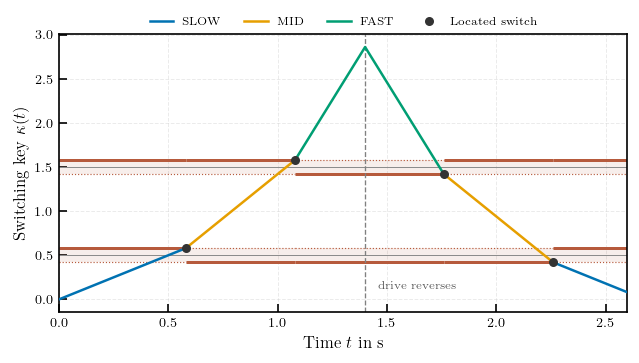

In [15]:
MODE_COLOR = {"SLOW": "#0072B2", "MID": "#E69F00", "FAST": "#009E73"}

# Mode intervals, rebuilt from the located switches.
edges = [T0] + [s["t"] for s in switches] + [REGION_T_END]
seq = [switches[0]["directed"].split(" -> ")[0]] + [
    s["directed"].split(" -> ")[1] for s in switches
]
intervals = list(zip(edges[:-1], edges[1:], seq))
region_of = {mode: i for i, mode in enumerate(MODES)}

fig, ax_key = plt.subplots(figsize=(0.92 * FULL_WIDTH, 0.53 * FULL_WIDTH))

for r, breakpoint_value in enumerate(BREAKPOINTS):
    ax_key.axhspan(breakpoint_value - BAND, breakpoint_value + BAND,
                   color="#B65A3C", alpha=0.10, linewidth=0)
    ax_key.axhline(breakpoint_value, color="0.55", linestyle="-", linewidth=0.6)
for t_start, t_stop, mode in intervals:
    for r, breakpoint_value in enumerate(BREAKPOINTS):
        armed = (breakpoint_value + BAND if region_of[mode] <= r
                 else breakpoint_value - BAND)
        other = (breakpoint_value - BAND if region_of[mode] <= r
                 else breakpoint_value + BAND)
        ax_key.plot([t_start, t_stop], [armed] * 2, color="#B65A3C", linewidth=1.8,
                    solid_capstyle="butt", zorder=2)
        ax_key.plot([t_start, t_stop], [other] * 2, color="#B65A3C", linewidth=0.7,
                    linestyle=":", zorder=2)
    inside = (t_key >= t_start) & (t_key <= t_stop)
    ax_key.plot(t_key[inside], key_num[inside], color=MODE_COLOR[mode],
                linewidth=1.5, zorder=3)
for mode in MODES:
    ax_key.plot([], [], color=MODE_COLOR[mode], linewidth=1.5, label=mode)
ax_key.plot([s["t"] for s in switches], [s["key"] for s in switches],
            linestyle="none", marker="o", markersize=4.5, color="0.2", zorder=4,
            label="Located switch")
ax_key.axvline(T_REVERSE, color="0.5", linestyle="--", linewidth=0.8)
ax_key.annotate("drive reverses", xy=(T_REVERSE, 0.12),
                xytext=(T_REVERSE + 0.06, 0.12), fontsize=7, color="0.35")
ax_key.set_xlim(T0, REGION_T_END)
ax_key.set_xlabel(r"Time $t$ in s")
ax_key.set_ylabel(r"Switching key $\kappa(t)$")
ax_key.grid(True, alpha=0.3)
ax_key.legend(loc="lower center", bbox_to_anchor=(0.5, 1.01),
              frameon=False, fontsize=7, ncol=4, borderaxespad=0)

fig.tight_layout()
fig.savefig(OUT_DIR / f"{FIGURE_ID}.pdf", bbox_inches="tight")
plt.show()

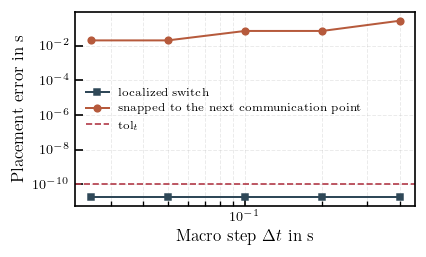

In [16]:
fig, ax = plt.subplots(figsize=(0.62 * FULL_WIDTH, 0.38 * FULL_WIDTH))
steps = list(placement_vs_step)
ax.loglog(steps, [placement_vs_step[s] for s in steps], marker="s", markersize=4,
          linewidth=1.2, color="#2F4858", label="localized switch")
ax.loglog(steps, [np.ceil(t_switch_exact / s) * s - t_switch_exact for s in steps],
          marker="o", markersize=4, linewidth=1.2, color="#B65A3C",
          label="snapped to the next communication point")
ax.axhline(TOL_TIME, color="#B23A48", linestyle="--", linewidth=1.0,
           label=r"$\mathrm{tol}_{t}$")
ax.set_xlabel(r"Macro step $\Delta t$ in s")
ax.set_ylabel("Placement error in s")
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="center left", frameon=False, fontsize=7)
fig.tight_layout()
fig.savefig(OUT_DIR / "V1b_placement_vs_step.pdf", bbox_inches="tight")
plt.show()


## Reading the result

**Placement.** With the indicator-value exit disabled, the bracket-width rule
located the exact crossing within `tol_time` for every tested macro step. This
is an exact-reference verification of the locator. It does not establish a
trajectory benefit or a general macro-step-independence claim.

**Hysteresis.** The same boundary arms at `breakpoint + band` while rising and
at `breakpoint - band` while falling. The measured difference is the full band
width.

**Adaptation.** The canonical quantity survives each representation change
because `_adapt_state` computes it. The synthetic path length is outside the
canonical interface and is discarded. The paper uses the measured FEM strain
energy, not this synthetic value, to quantify physical loss.

**Partners.** The partner advances between every consecutive pair of switches
and remains monotone across the run. It has no knowledge that the active plant
model changed.

The multi-boundary and chattering edge cases are covered by
`tests/unit/core/test_multi_comp.py` and
`tests/integration/test_multi_comp_switching.py` rather than repeated here.